<a href="https://colab.research.google.com/github/zhakeenski/CarCareManagementSystem/blob/master/Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  1. DATASET STRUCTURE
Rows: 151   Columns: 5   Duplicates: 3   Missing values: 5



,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,dtype,non-null,unique
SepalLength,float64,150,35
SepalWidth,float64,150,23
PetalLength,float64,150,43
PetalWidth,float64,150,22
Species,object,150,3



Class balance:


,count
Species,
setosa,50
versicolor,50
virginica,50



  2. SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
SepalLength,150.000000,5.840000,0.830000,4.300000,5.100000,5.800000,6.400000,7.900000
SepalWidth,150.000000,3.050000,0.430000,2.000000,2.800000,3.000000,3.300000,4.400000
PetalLength,150.000000,3.760000,1.760000,1.000000,1.600000,4.350000,5.100000,6.900000
PetalWidth,150.000000,1.200000,0.760000,0.100000,0.300000,1.300000,1.800000,2.500000



Mean and std per species:


SepalLength       SepalWidth       PetalLength       PetalWidth  \
                  mean   std       mean   std        mean   std       mean   
Species                                                                      
setosa            5.01  0.35       3.42  0.38        1.46  0.17       0.24   
versicolor        5.94  0.52       2.77  0.31        4.26  0.47       1.33   
virginica         6.59  0.64       2.97  0.32        5.55  0.55       2.03   

                  
             std  
Species           
setosa      0.11  
versicolor  0.20  
virginica   0.27


  3. DISTRIBUTIONS


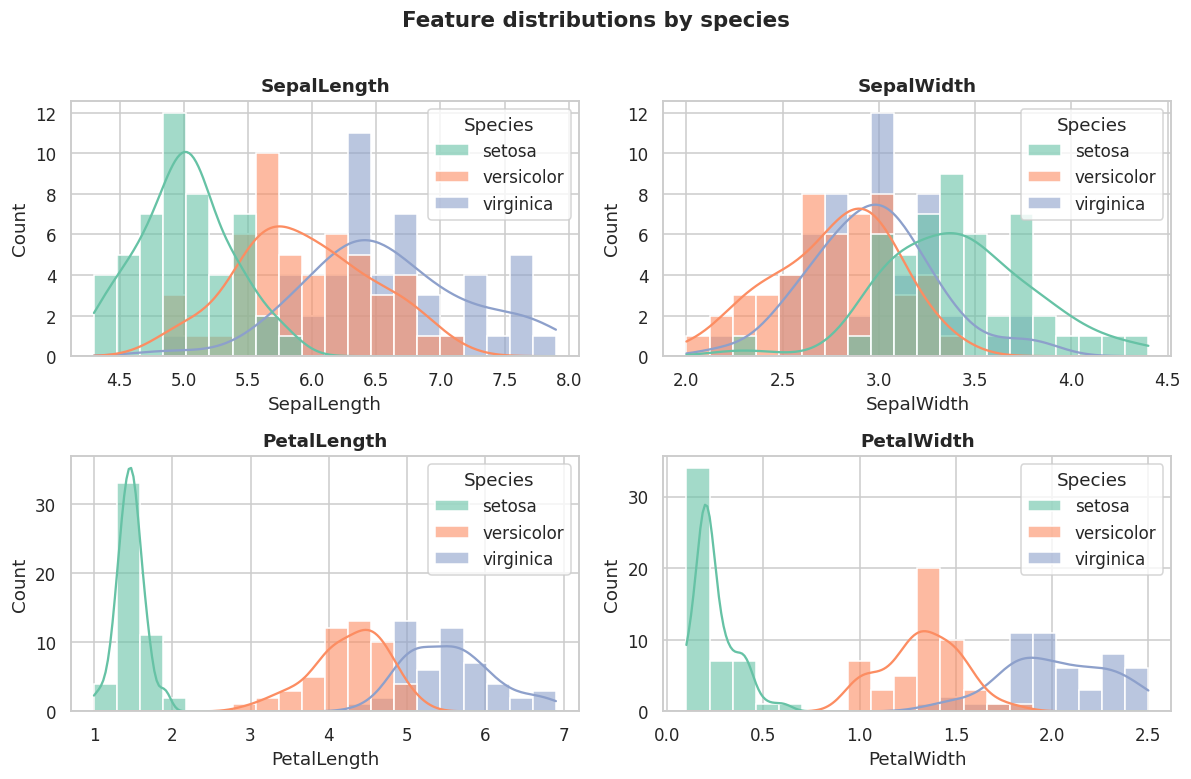


  4. BOXPLOTS (OUTLIERS AND SPREAD)


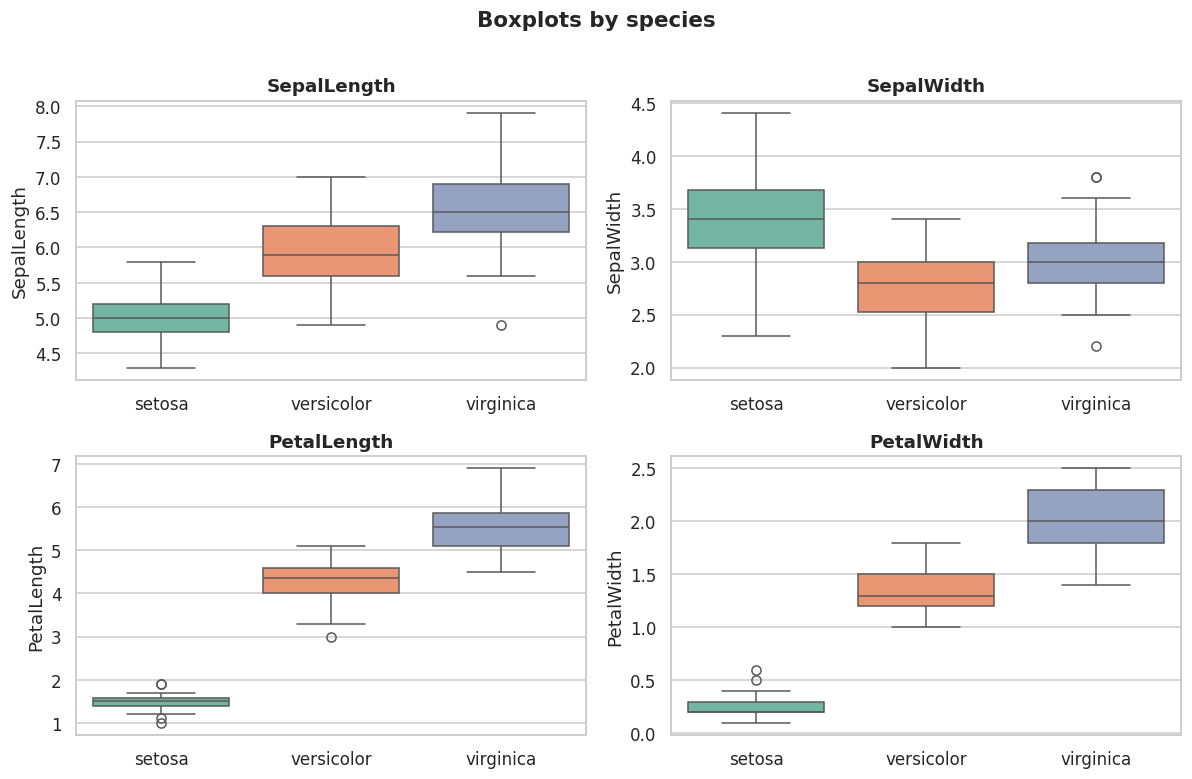


  5. PAIRPLOT


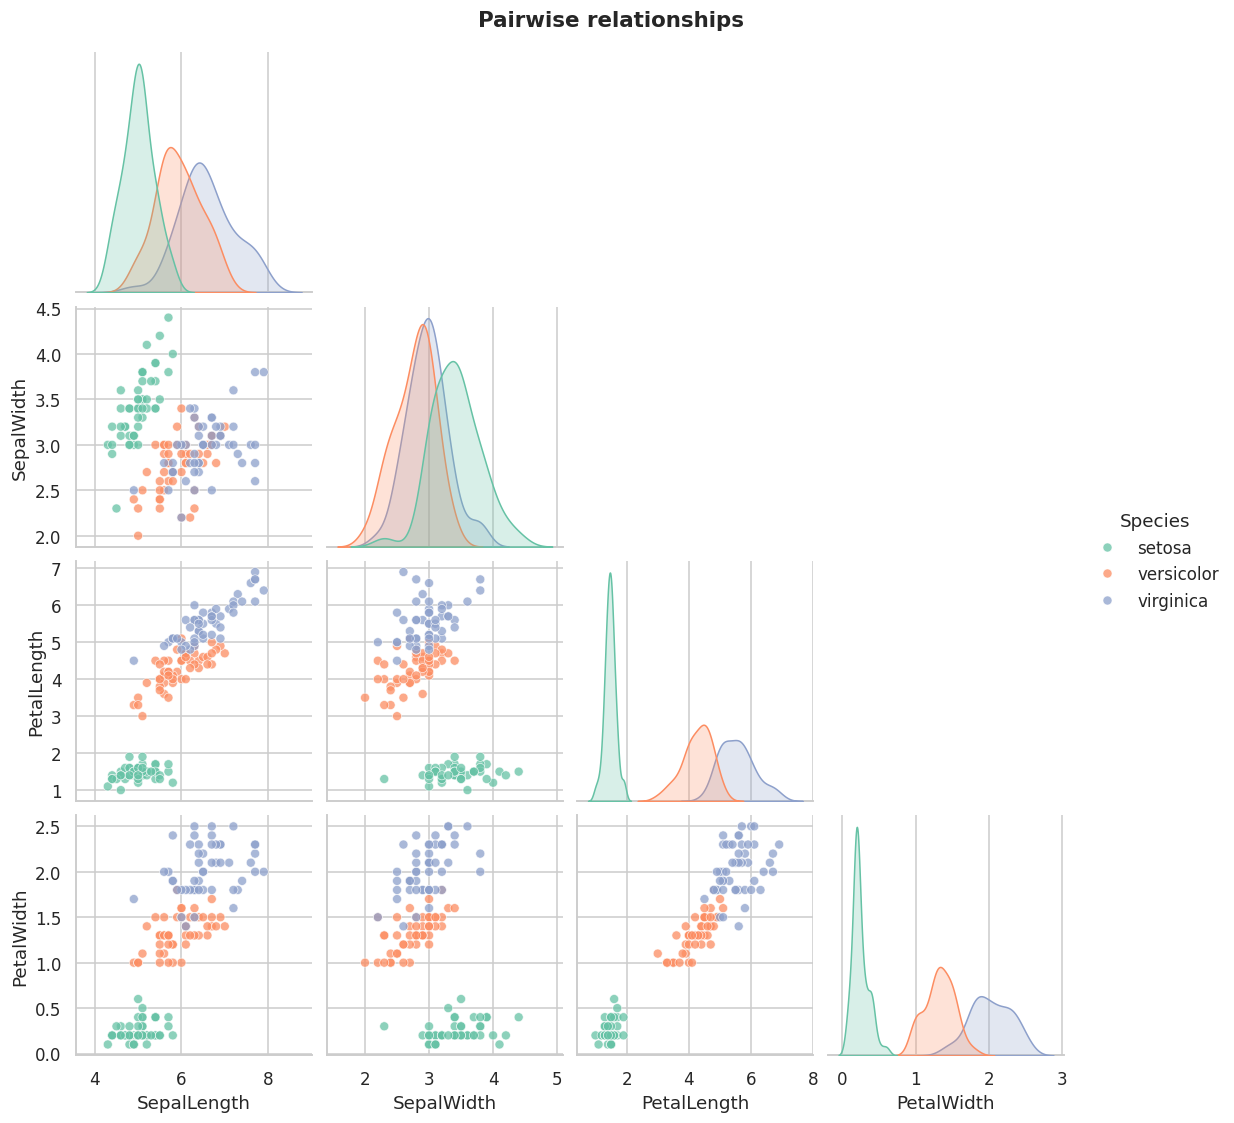


  6. CORRELATION


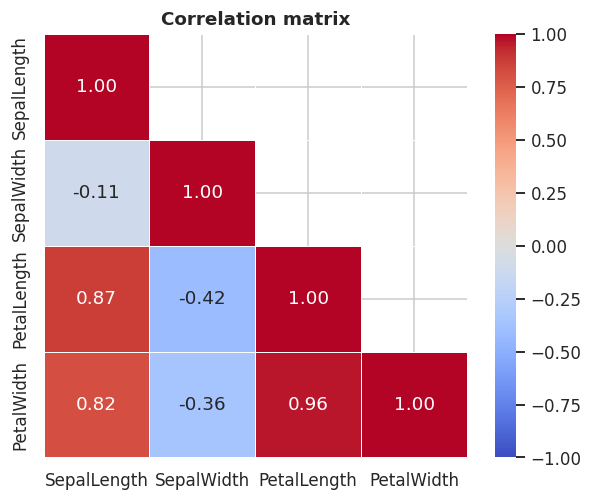


  7. OUTLIERS (IQR RULE)


,outliers
SepalLength,0
SepalWidth,4
PetalLength,0
PetalWidth,0



Outlier rows:


,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


In [1]:
import pandas as pd, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# ---------- Setup ----------
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})

def section(title):
    print("\n" + "=" * 60 + f"\n  {title}\n" + "=" * 60)

# ---------- Load ----------
df = pd.read_csv("Iris.csv")
df = df.drop(columns=[c for c in df.columns if c.lower() == "id"])        # drop Kaggle Id column
df.columns = [c.replace("Cm", "").strip() for c in df.columns]            # SepalLengthCm -> SepalLength
target = df.select_dtypes(exclude="number").columns[0]
df[target] = df[target].str.replace("Iris-", "", regex=False)             # Iris-setosa -> setosa
num = df.select_dtypes(include="number").columns.tolist()
palette = dict(zip(df[target].unique(), sns.color_palette("Set2", df[target].nunique())))

# ---------- 1. Structure ----------
section("1. DATASET STRUCTURE")
print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}   Duplicates: {df.duplicated().sum()}   Missing values: {df.isna().sum().sum()}\n")
display(df.head())
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "non-null": df.notna().sum(), "unique": df.nunique()}))
print("\nClass balance:")
display(df[target].value_counts().to_frame("count"))

# ---------- 2. Summary statistics ----------
section("2. SUMMARY STATISTICS")
display(df[num].describe().T.round(2).style.background_gradient(cmap="Blues", subset=["mean", "std"]))
print("\nMean and std per species:")
display(df.groupby(target)[num].agg(["mean", "std"]).round(2))

# ---------- 3. Distributions ----------
section("3. DISTRIBUTIONS")
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), num):
    sns.histplot(data=df, x=col, hue=target, palette=palette, kde=True, bins=20, alpha=.6, ax=ax)
    ax.set_title(col)
fig.suptitle("Feature distributions by species", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

# ---------- 4. Boxplots ----------
section("4. BOXPLOTS (OUTLIERS AND SPREAD)")
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.ravel(), num):
    sns.boxplot(data=df, x=target, y=col, hue=target, palette=palette, legend=False, ax=ax)
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle("Boxplots by species", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

# ---------- 5. Pairwise relationships ----------
section("5. PAIRPLOT")
g = sns.pairplot(df, hue=target, palette=palette, corner=True, diag_kind="kde", plot_kws={"alpha": .75, "s": 35})
g.figure.suptitle("Pairwise relationships", fontsize=14, fontweight="bold", y=1.02)
plt.show()

# ---------- 6. Correlation ----------
section("6. CORRELATION")
corr = df[num].corr()
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, linewidths=.5, square=True)
plt.title("Correlation matrix"); plt.show()

# ---------- 7. Outliers (IQR rule) ----------
section("7. OUTLIERS (IQR RULE)")
q1, q3 = df[num].quantile(.25), df[num].quantile(.75); iqr = q3 - q1
mask = (df[num] < q1 - 1.5 * iqr) | (df[num] > q3 + 1.5 * iqr)
display(mask.sum().to_frame("outliers"))
if mask.any(axis=None):
    print("\nOutlier rows:"); display(df[mask.any(axis=1)])